# YOLOv8

In [1]:
# /home/chen_le/miniforge3/envs/tmnf_mmdet/bin/python
# /home/chen_le/miniforge3/envs/tmnf_mmdet/bin/pip

#!which python
#!which pip

### Data Preparation

In [2]:
# Depending on dataset size can take very long
# !./_data_preparation.sh

### Training

In [3]:
# Train with yolov8
# !./_train.sh

### Extraction

In [ ]:
# Extraction
# !./extract_feat_yolo.sh

### Inference

In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import random
import cv2
import numpy as np

def _read_imageset(imageset_path):
    """
    Reads a YOLO/VOC-style imageset .txt and returns a list of image paths.
    - Lines may be absolute or relative paths.
    - If a line has no file extension, '.jpg' is appended (common in VOC lists).
    - Empty lines and comments (# ...) are ignored.
    """
    imageset_path = Path(imageset_path)
    lines = imageset_path.read_text().splitlines()
    roots_to_try = [imageset_path.parent, Path.cwd()]  # for resolving relative paths

    img_paths = []
    for raw in lines:
        s = raw.strip()
        if not s or s.startswith('#'):
            continue
        p = Path(s)
        # If no extension, try .jpg
        if p.suffix == "":
            p_jpg = p.with_suffix(".jpg")
            candidates = [p, p_jpg]
        else:
            candidates = [p]

        resolved = None
        for c in candidates:
            if c.is_absolute() and c.exists():
                resolved = c
                break
            # try relative to imageset directory and CWD
            for root in roots_to_try:
                cand = (root / c).resolve()
                if cand.exists():
                    resolved = cand
                    break
            if resolved is not None:
                break

        # If nothing exists, keep the original string (Ultralytics can still try to read it)
        img_paths.append(resolved if resolved is not None else p)

    return [str(p) for p in img_paths]

def _draw_detections(ax, img_rgb, boxes_xyxy, confs, clses, class_names):
    ax.imshow(img_rgb)
    ax.axis('off')
    h, w = img_rgb.shape[:2]
    # Thickness and font size scaled to image size
    thick = max(1, int(round(0.002 * (h + w))))
    fs = max(8, int(round(0.003 * (h + w))))

    for (x1, y1, x2, y2), cf, cl in zip(boxes_xyxy, confs, clses):
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            fill=False, linewidth=thick
        )
        ax.add_patch(rect)
        name = class_names[int(cl)] if class_names and int(cl) in class_names else str(int(cl))
        label = f"{name} {cf:.2f}"
        # Text background
        txt_width = max(1, int(0.4 * fs))
        ax.add_patch(patches.Rectangle((x1, max(0, y1 - fs - txt_width)), 0, 0))  # noop for layout
        ax.text(x1, max(0, y1 - 2), label, fontsize=fs, color='white',
                bbox=dict(facecolor='black', alpha=0.5, pad=2))

def visualize_batch(model_path, imageset_txt, n=9, imgsz=1280, conf=0.25, iou=0.45, device=None, seed=None):
    """
    Visualize a batch of detections from a YOLOv8 model on a 3x3 grid.

    Args:
        model_path: path to YOLOv8 weights (.pt)
        imageset_txt: path to imageset .txt (each line an image path; ext optional)
        n: number of images to visualize (default 9)
        imgsz: inference image size
        conf: confidence threshold
        iou: NMS IoU threshold
        device: e.g. 'cuda:0' or 'cpu' (None lets YOLO decide)
        seed: set for reproducible sampling
    """
    if seed is not None:
        random.seed(seed)

    model = YOLO(model_path)
    class_names = model.names  # dict like {0:'class0', ...}

    all_paths = _read_imageset(imageset_txt)
    if len(all_paths) == 0:
        raise ValueError(f"No valid image paths found in {imageset_txt}")
    sample_paths = random.sample(all_paths, min(n, len(all_paths)))

    # Run inference in one go; Ultralytics returns a list of Results
    results = model(
        sample_paths,
        imgsz=imgsz,
        conf=conf,
        iou=iou,
        device=device,
        verbose=False
    )

    # Prepare grid
    rows = cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(16, 16))
    axes = axes.flatten()

    for ax in axes[len(results):]:
        ax.axis('off')

    for ax, img_path, res in zip(axes, sample_paths, results):
        # Load image (OpenCV -> RGB)
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            ax.text(0.5, 0.5, f"Could not read:\n{img_path}", ha='center', va='center')
            ax.axis('off')
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Extract detections
        if res.boxes is not None and len(res.boxes) > 0:
            xyxy = res.boxes.xyxy.cpu().numpy()
            confs = res.boxes.conf.cpu().numpy()
            clses = res.boxes.cls.cpu().numpy()
        else:
            xyxy = np.zeros((0, 4), dtype=np.float32)
            confs = np.zeros((0,), dtype=np.float32)
            clses = np.zeros((0,), dtype=np.int32)

        _draw_detections(ax, img_rgb, xyxy, confs, clses, class_names)
        ax.set_title(Path(img_path).name, fontsize=12)

    plt.tight_layout()
    plt.show()


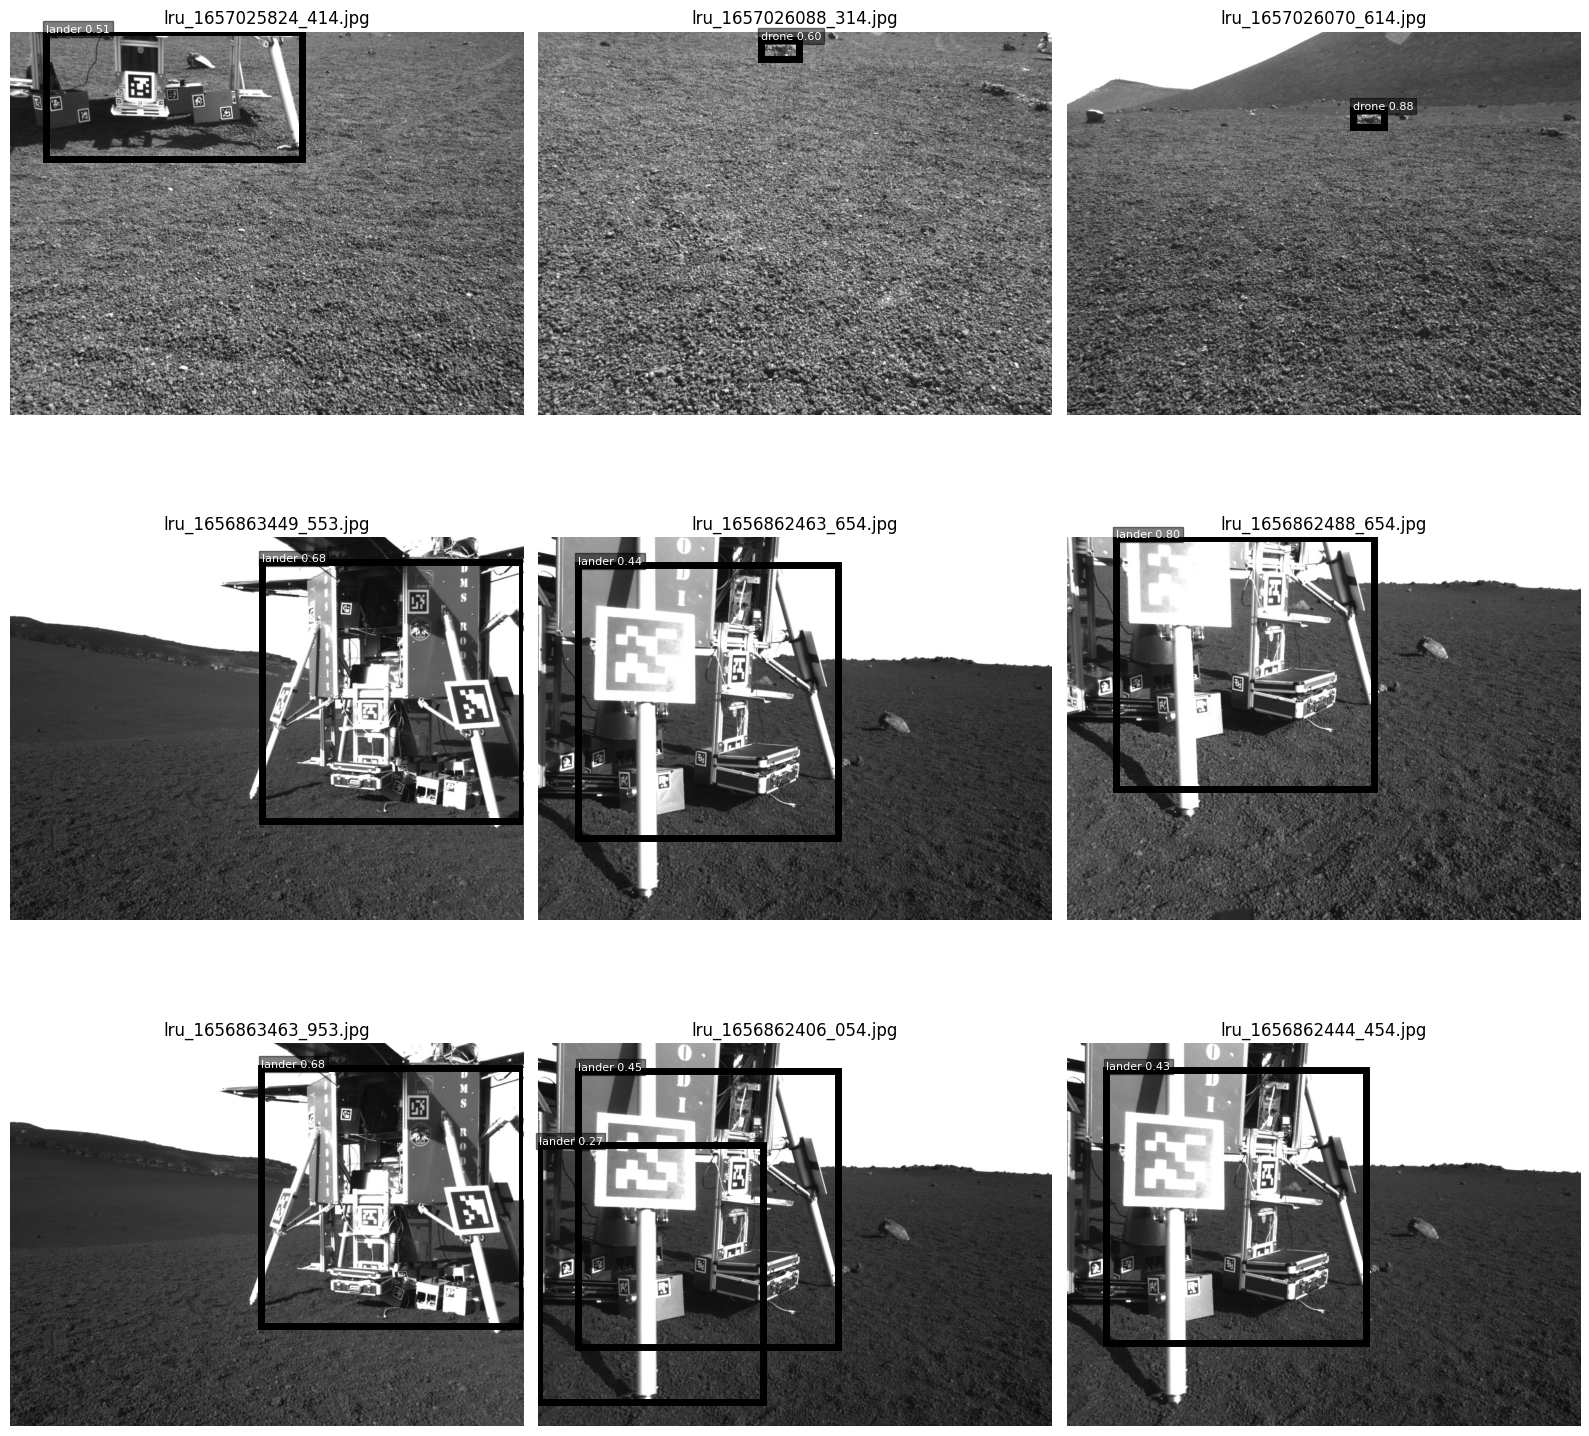

In [7]:
model_path = '/home/chen_le/openset_detection/scripts/YOLOv8/training/runs/detect/train_lru1_lru2/weights/best.pt'
image_dir = '/volume/hot_storage/slurm_data/chen_le/ARCHES/lru1_all/ImageSets/YOLO_CS_lru2/train.txt'

visualize_batch(model_path, image_dir)

### Extract logits for TMNF (WIP)

Processed 1 boxes
[{'activations': [0.9835330843925476, 1.0255045879148383e-07],
  'bbox': [0.95050048828125, 0.0, 757.3804321289062, 910.8787231445312],
  'bbox_xywh': [379.16546630859375,
                455.4393615722656,
                756.429931640625,
                910.8787231445312],
  'best_cls': 0.0,
  'best_conf': 0.9835330843925476,
  'image_id': '/media/chen/76AECF8EAECF4579/data/lru1_all_labels/VOCdevkit/VOC2007CS_lru2/splits/images/test/lru_1656862409_554.jpg',
  'logits': [4.089800834655762, -16.092910766601562]}]


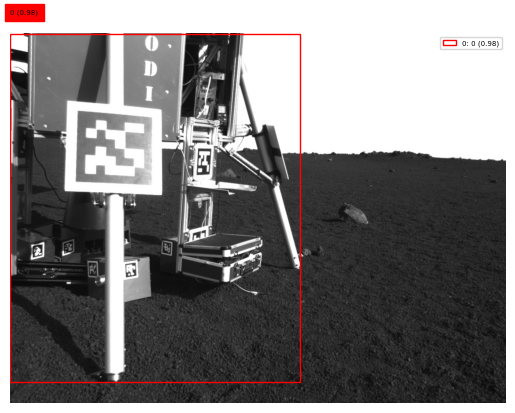

In [5]:
# Extract logits and reproduce inference results
from extraction.feat_extraction_yolo import *
import pprint

# Configuration
model_path = 'training/runs/detect/train_lru2/weights/best.pt'
img_path = '/media/chen/76AECF8EAECF4579/data/lru1_all_labels/VOCdevkit/VOC2007CS_lru2/splits/images/test/lru_1656862409_554.jpg'

# Load model and run inference
model, hooks = load_and_prepare_model(model_path)
results = run_predict_single(img_path, model,
                      hooks,
                      num_classes=2,
                      conf_threshold=0.5,
                      iou_threshold=0.7)

print("Processed", len(results), "boxes")
plot_image(img_path, results)
pprint.pprint(results)
# write_json(results)

In [ ]:
from extraction.feat_extraction_yolo import *

# Config
model_path = 'training/runs/detect/ardea10/weights/best.pt'
image_dir = '/media/chen/76AECF8EAECF4579/data/ardea10_run04_labels/VOCdevkit/VOC2007CS_lru2/splits/images/'

# Extract logits from trained YOLO model
splits = ['test', 'train', 'val']
for split in splits:
    print(f'{image_dir}/{split}/')
    results = run_inference_yolo(model_path,
                            f'{image_dir}/{split}/',
                            num_classes=2,
                            confThresh=0.2,
                            iouThresh=0.7)
    # TODO: Setting path
    save_results_json(results, f'/home/chen/TMNF/data/extracted_feat/flowDet_msfeats/YOLOv8/associated/VOCDataset/extraction_{split}')

In [ ]:
from extraction.pred_assignment_yolo import *

splits = ['train', 'val', 'test']
for split in splits:
    pred_assignment(split, 2, 0.2, 0.7)